# ALMOND TYPES CLASSIFICATION

**Dataset:** 09

**Group:** 11 

**Members:** 016, 017, 027  

# 1. Define the Problem and Load the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# Load the dataset
df = pd.read_csv("Dataset_9.csv")

# Display the first few rows to confirm loading
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   Unnamed: 0  Length (major axis)  Width (minor axis)  Thickness (depth)  \
0           0                  NaN          227.940628         127.759132   
1           1                  NaN          234.188126         128.199509   
2           2                  NaN          229.418610         125.796547   
3           3                  NaN          232.763153         125.918808   
4           4                  NaN          230.150742         107.253448   

      Area   Perimeter  Roundness  Solidity  Compactness  Aspect Ratio  \
0  22619.0  643.813269        NaN  0.973384     1.458265           NaN   
1  23038.0  680.984841        NaN  0.957304     1.601844           NaN   
2  22386.5  646.943212        NaN  0.967270     1.487772           NaN   
3  22578.5  661.227483        NaN  0.965512     1.540979           NaN   
4  19068.0  624.842706        NaN  0.951450     1.629395           NaN   

   Eccentricity    Extent  Convex hull(convex area)   Type  
0 

In [3]:
# Display dataset summary to understand structure and missing values
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2803 entries, 0 to 2802
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2803 non-null   int64  
 1   Length (major axis)       1946 non-null   float64
 2   Width (minor axis)        1861 non-null   float64
 3   Thickness (depth)         1799 non-null   float64
 4   Area                      2803 non-null   float64
 5   Perimeter                 2803 non-null   float64
 6   Roundness                 1946 non-null   float64
 7   Solidity                  2803 non-null   float64
 8   Compactness               2803 non-null   float64
 9   Aspect Ratio              1004 non-null   float64
 10  Eccentricity              1004 non-null   float64
 11  Extent                    2803 non-null   float64
 12  Convex hull(convex area)  2803 non-null   float64
 13  Type                      2803 non-null   str    
dt

# 2. Data Preprocessing

In [4]:
# 1. Drop unnecessary columns (if any, like 'Unnamed: 0')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 2. Separate Features (X) and Target (y)
X = df.drop(columns=['Type'])
y = df['Type']

# 3. Handle Missing Values
# We use mean imputation to fill missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# 4. Encode the Target Variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 5. Feature Scaling
# Standardization (scaling to mean=0, variance=1) is crucial for many models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 6. Split the Data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

# Verify the preprocessing
print("Preprocessed Data Shape:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Unique classes in target: {label_encoder.classes_}")

Preprocessed Data Shape:
X_train shape: (2242, 12)
X_test shape: (561, 12)
y_train shape: (2242,)
Unique classes in target: ['MAMRA' 'REGULAR' 'SANORA']


# 3. Exploratory Data Analysis

In [5]:
# 1. Descriptive Statistics
print("Descriptive Statistics:")
print(df.describe())

Descriptive Statistics:
       Length (major axis)  Width (minor axis)  Thickness (depth)  \
count          1946.000000         1861.000000        1799.000000   
mean            290.609274          171.025915         109.705378   
std              62.719433           29.916529          18.940597   
min             151.335266           88.050529          59.494278   
25%             245.966293          149.453659          97.091682   
50%             279.879883          170.168365         110.280136   
75%             330.508575          190.640427         121.392773   
max             515.352478          258.569794         181.845200   

               Area    Perimeter    Roundness     Solidity  Compactness  \
count   2803.000000  2803.000000  1946.000000  2803.000000  2803.000000   
mean   26511.117374   743.863770     0.470466     0.955828     1.825233   
std    13782.561344   230.632076     0.118673     0.039596     0.794058   
min     6037.000000   311.563489     0.173748     0.71

In [6]:
# 2. Check for missing values
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
Length (major axis)          857
Width (minor axis)           942
Thickness (depth)           1004
Area                           0
Perimeter                      0
Roundness                    857
Solidity                       0
Compactness                    0
Aspect Ratio                1799
Eccentricity                1799
Extent                         0
Convex hull(convex area)       0
Type                           0
dtype: int64


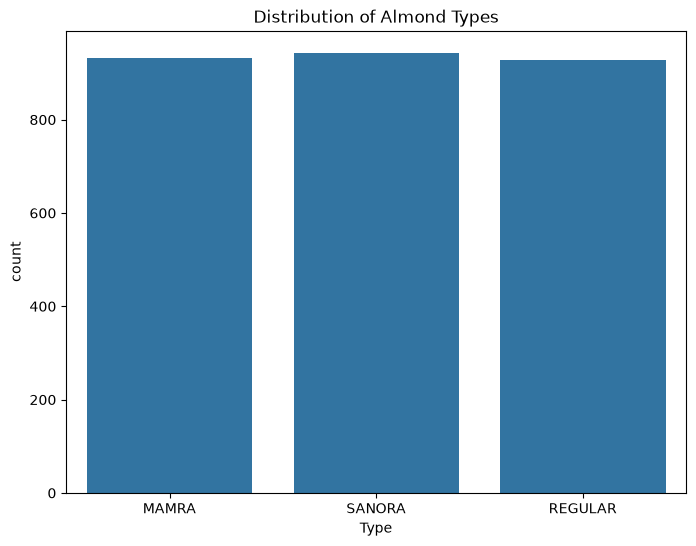

In [7]:
# Plot distribution of the target variable 'Type'
plt.figure(figsize=(8, 6))
sns.countplot(x='Type', data=df)
plt.title('Distribution of Almond Types')
plt.show()

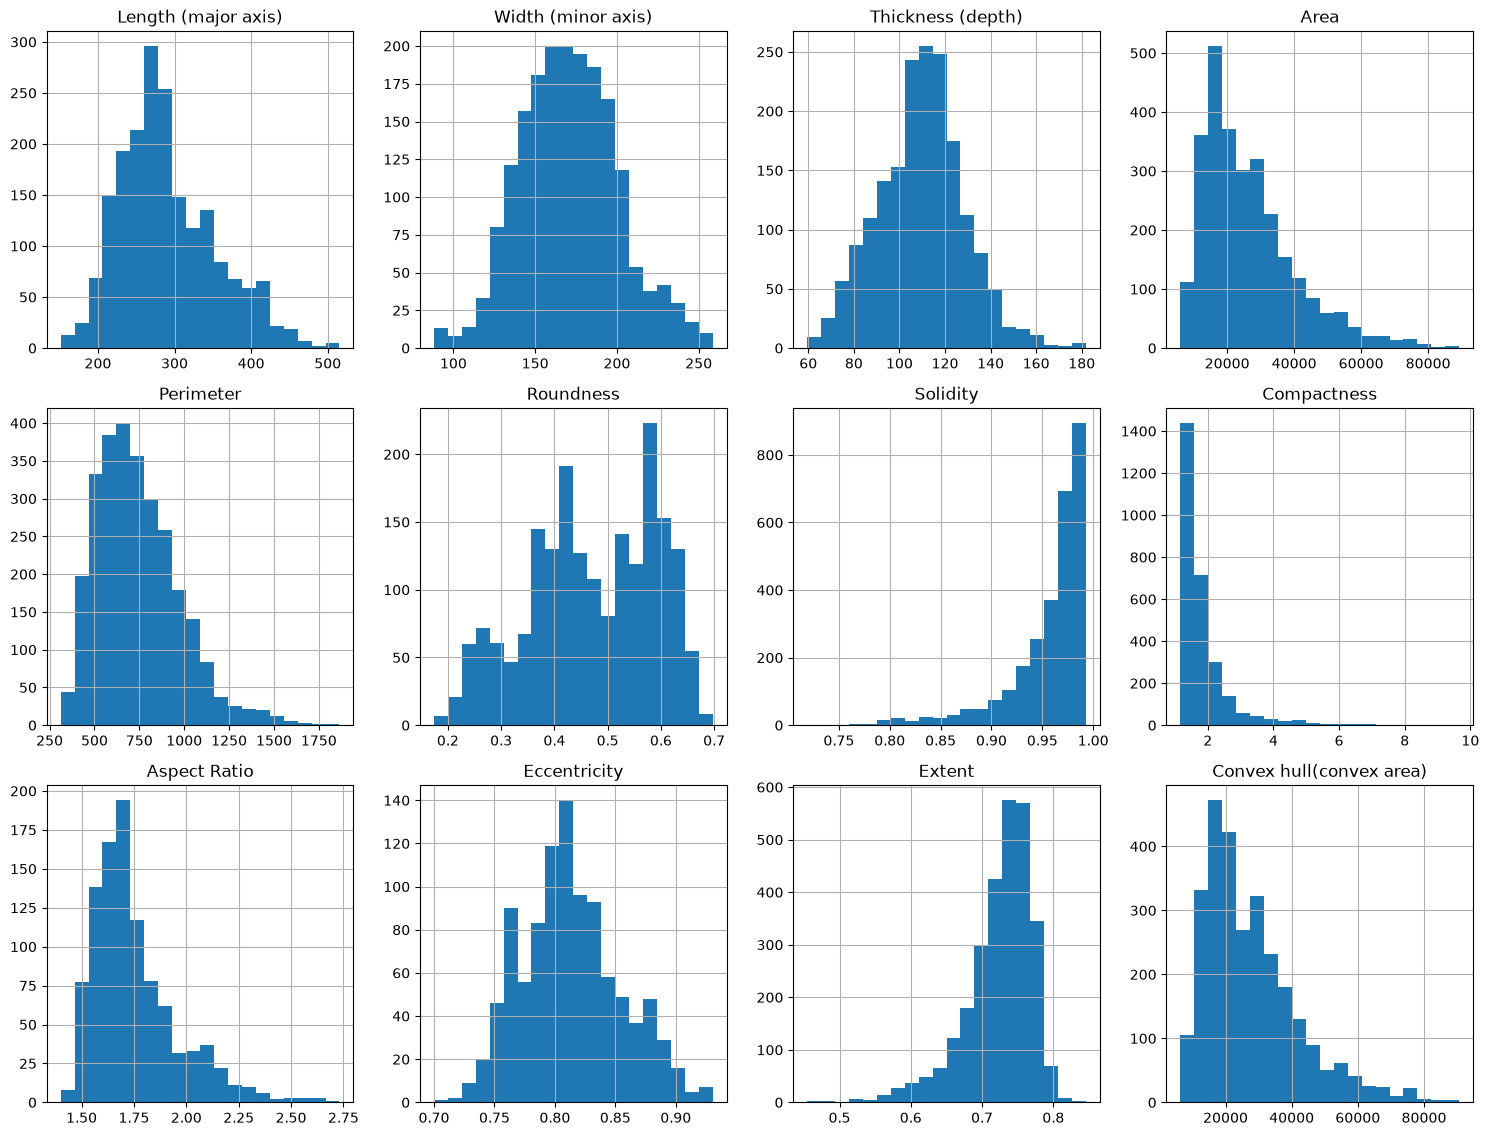

In [8]:
# Plot histograms for numeric features
df.hist(bins=20, figsize=(15, 15), layout=(4, 4))
plt.tight_layout()
plt.show()

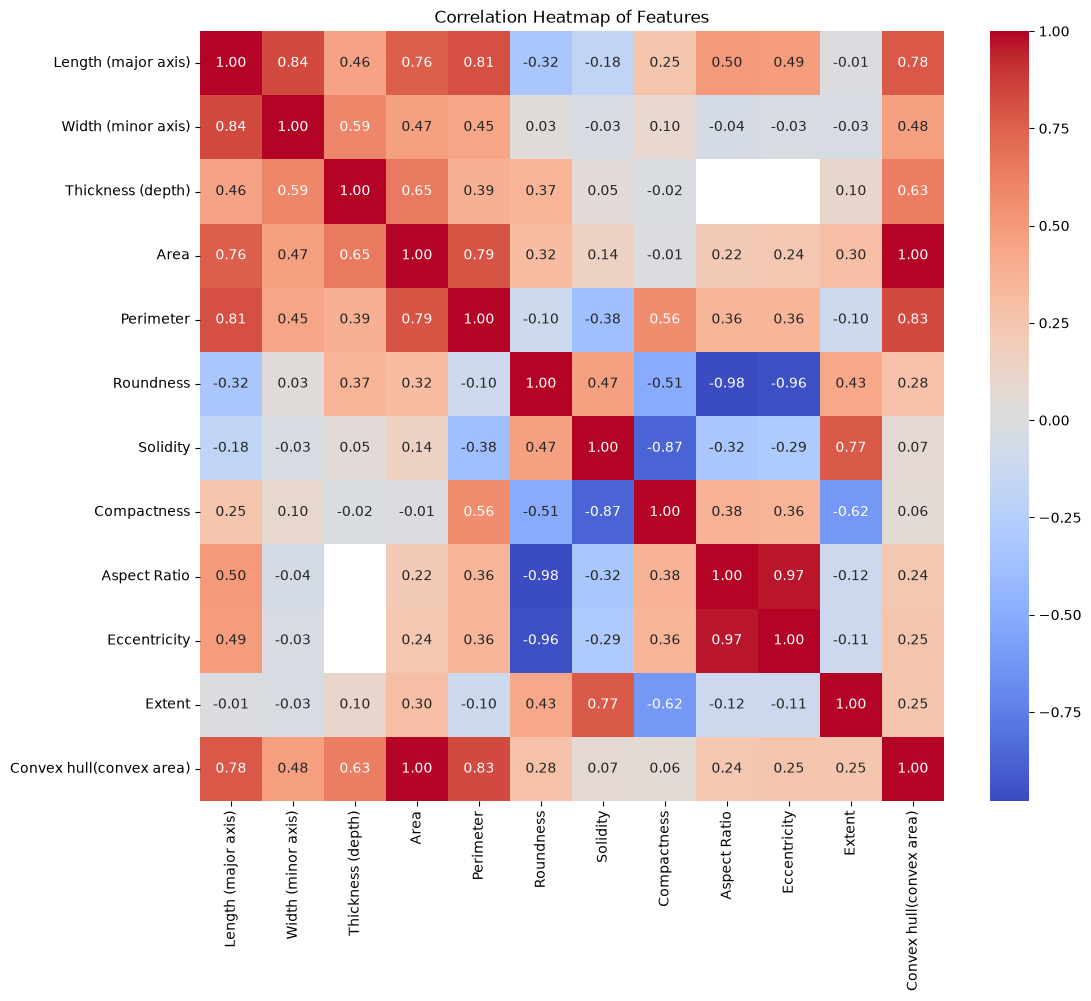

In [9]:
import numpy as np
# Correlation Heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

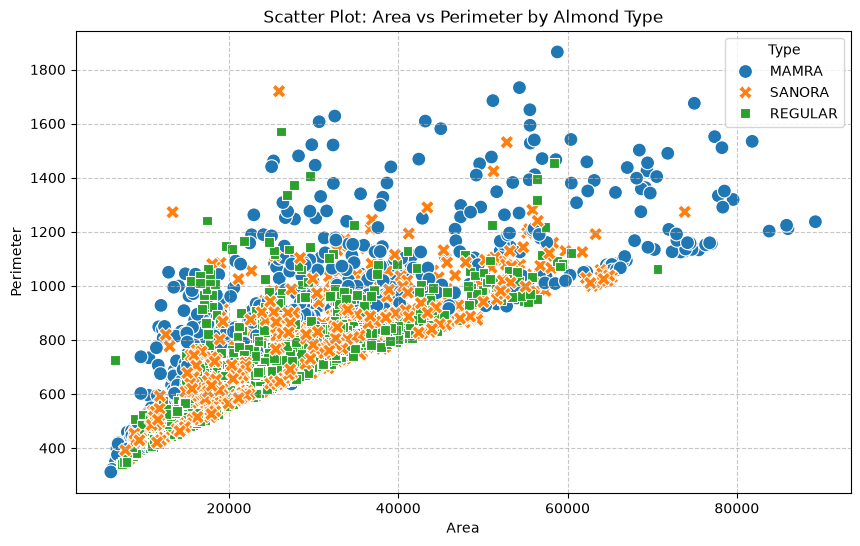

In [10]:
# Scatter plot code breakdown
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Area', y='Perimeter', hue='Type', style='Type', s=100)
plt.title('Scatter Plot: Area vs Perimeter by Almond Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4. Feature Engineering

In [11]:
# Convert columns to numeric explicitly
df['Length (major axis)'] = pd.to_numeric(df['Length (major axis)'], errors='coerce')
df['Width (minor axis)'] = pd.to_numeric(df['Width (minor axis)'], errors='coerce')

# Calculate the ratio and fill missing values
aspect_ratio_calculated = df['Length (major axis)'] / df['Width (minor axis)']
mask = df['Aspect Ratio'].isna()
df.loc[mask, 'Aspect Ratio'] = aspect_ratio_calculated[mask]

# 3. Data Preprocessing
# Separate Features and Target
X = df.drop(columns=['Type'])
y = df['Type']

# Handle remaining missing values (impute with mean)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Encode Target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 4. Feature Scaling and Selection
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Feature Selection (Select top 5)
selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X_scaled, y_encoded)

# 5. Split the Data
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_encoded, test_size=0.2, random_state=42
)

# Output status
print("Preprocessing and Feature Engineering Complete.")
print(f"X_train shape: {X_train.shape}")
print(f"Features selected: {selector.get_support(indices=True)}")

Preprocessing and Feature Engineering Complete.
X_train shape: (2242, 5)
Features selected: [0 5 6 8 9]


# 5. Split the Data into Training and Testing Sets

In [12]:
# Assuming 'X_selected' contains our chosen features and 'y_encoded' is the target
# We perform a 80/20 split, which is a standard industry practice
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, 
    y_encoded, 
    test_size=0.2,       # 20% of data goes to the test set
    random_state=42,     # Ensures reproducibility of the results
    stratify=y_encoded   # Ensures class balance is maintained in both sets
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 2242 samples
Testing set size: 561 samples


# 6. Choose and Train a Model

In [13]:
# 1. Initialize the Model
# n_estimators defines the number of trees in the forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the Model
rf_model.fit(X_train, y_train)

# 3. Make Predictions
y_pred = rf_model.predict(X_test)

# 4. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Model Accuracy: 0.7219

Classification Report:
              precision    recall  f1-score   support

       MAMRA       0.80      0.82      0.81       187
     REGULAR       0.68      0.63      0.65       185
      SANORA       0.68      0.72      0.70       189

    accuracy                           0.72       561
   macro avg       0.72      0.72      0.72       561
weighted avg       0.72      0.72      0.72       561



# 7. Hyperparameter Tuning (Optimization)

In [14]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# 2. Initialize the Grid Search
# We use cross-validation (cv=5) to ensure the results are reliable
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,  # Use all available CPU cores
    scoring='accuracy'
)

# 3. Fit the search
grid_search.fit(X_train, y_train)

# 4. Results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# 5. Evaluate the optimized model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
print(f"Test Set Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Score: 0.6887
Test Set Accuracy: 0.6988


# 8. Make Predictions

In [19]:
import joblib

# 1. Load the saved components
loaded_package = joblib.load('model_package.pkl')
model = loaded_package['model']
scaler = loaded_package['scaler']
imputer = loaded_package['imputer']
selector = loaded_package['selector']
label_encoder = loaded_package['label_encoder']

# 2. Define the prediction function using the loaded components
def predict_object_type(new_data_dict):
    new_df = pd.DataFrame([new_data_dict])
    
    # Process the data using the loaded pipeline
    imputed = imputer.transform(new_df)
    scaled = scaler.transform(imputed)
    selected = selector.transform(scaled)
    
    # Predict
    prediction_idx = model.predict(selected)
    return label_encoder.inverse_transform(prediction_idx)[0]

# 3. Define the input data (The sample_data that was missing)
sample_data = {
    "Length (major axis)": 227.94,
    "Width (minor axis)": 127.75,
    "Thickness (depth)": 107.25,
    "Area": 22619.0,
    "Perimeter": 643.81,
    "Roundness": 0.95,
    "Solidity": 0.97,
    "Compactness": 1.45,
    "Aspect Ratio": 1.78,
    "Eccentricity": 0.65,
    "Extent": 0.68,
    "Convex hull(convex area)": 23237.5
}

# 4. Execute the prediction
predicted_type = predict_object_type(sample_data)
print(f"The predicted type for the input is: {predicted_type}")

The predicted type for the input is: REGULAR


# 9. Evaluate the Model

<Figure size 800x600 with 0 Axes>

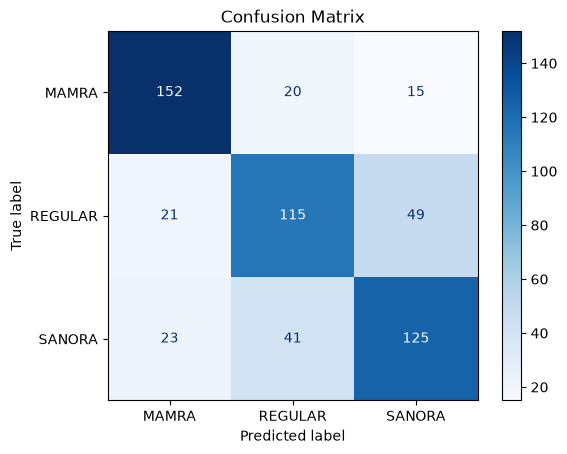

Cross-Validation Scores: [0.6684492  0.63279857 0.55793226 0.675      0.53571429]
Average CV Accuracy: 0.6140 (+/- 0.0571)


In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

# 1. Confusion Matrix
# This shows exactly which classes are being confused with others
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# 2. Cross-Validation Score
# This ensures the model's performance isn't just a result of a 'lucky' train/test split
cv_scores = cross_val_score(best_rf, X_scaled, y_encoded, cv=5)
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Average CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 10. Save and Load the Model

In [17]:
import joblib

# Create a dictionary to hold all components
model_package = {
    'model': best_rf,
    'scaler': scaler,
    'imputer': imputer,
    'selector': selector,
    'label_encoder': label_encoder
}

# Save the package to a file
joblib.dump(model_package, 'model_package.pkl')
print("Model and preprocessing components saved successfully.")

Model and preprocessing components saved successfully.


In [18]:
# Load the package
loaded_package = joblib.load('model_package.pkl')

# Extract components
model = loaded_package['model']
scaler = loaded_package['scaler']
imputer = loaded_package['imputer']
selector = loaded_package['selector']
label_encoder = loaded_package['label_encoder']

# Now you can use 'model' and the other components for predictions
# (using the predict_object_type function we defined in Step 8)